In [1]:
import json

In [2]:
# merge 2 files Class_9_final.json and Class_10_final.json into one file called Class_9_10_final.json

with open('2-processed/stem.json', 'r') as f:
    stem = json.load(f)

with open('2-processed/ustad_360_others.json', 'r') as f:
    ustad_360_others = json.load(f)

with open('2-processed/ustad_360_stem.json', 'r') as f:
    ustad_360_stem = json.load(f)

data = stem + ustad_360_others + ustad_360_stem

# if any question is duplicate in data, remove it (based on question text) and keep the first occurrence
seen_questions = set()

unique_data = []
for item in data:
    question = item['question']
    if question not in seen_questions:
        unique_data.append(item)
        seen_questions.add(question)

print(f"Total questions after merging: {len(data)}")
print(f"Total unique questions after merging: {len(unique_data)}")

Total questions after merging: 30931
Total unique questions after merging: 30830


In [3]:
data[0]

{'id': 0,
 'question_number': 1,
 'question': 'آرٹ کی اقسام ہوتی ہیں۔',
 'options': {'A': 'چار', 'B': 'ایک', 'C': 'دو', 'D': 'تین'},
 'has_image': False,
 'image_bbox': None,
 'domain': 'Humanities',
 'subdomain': 'art and drawing',
 'correct_option': None,
 'correct_index': None,
 'level': 'SSC-II',
 'page': 1,
 'source_url': '',
 'source_image': 'AMD 10th_page_0001.jpg',
 'folder': 'AMD 10th',
 'provider': 'gemini',
 'model': 'gemini-3-flash-preview',
 'source': 'BISE Multan 2025'}

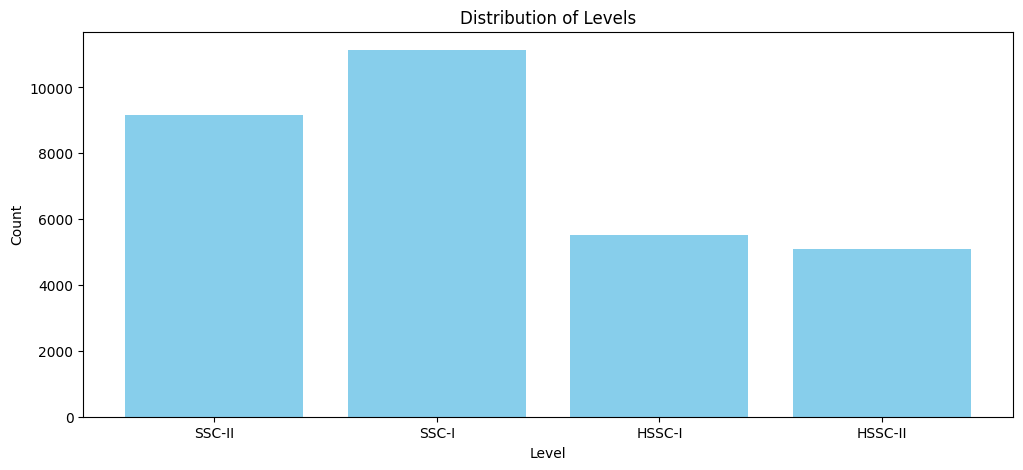

In [4]:
# check distribution of levels and subdomains through bar plots.
import matplotlib.pyplot as plt
from collections import Counter

levels = [item['level'] for item in data]
level_counts = Counter(levels)

plt.figure(figsize=(12, 5))
plt.bar(level_counts.keys(), level_counts.values(), color='skyblue')
plt.title('Distribution of Levels')
plt.xlabel('Level')
plt.ylabel('Count')
plt.show()

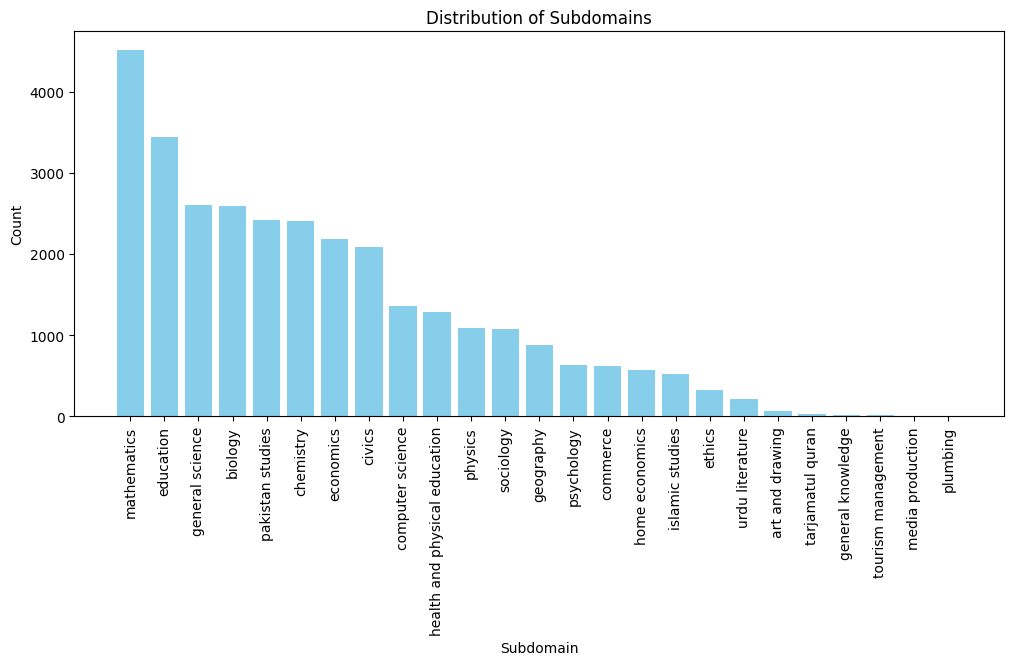

In [5]:
# len of unique subdomains
subdomains = [item['subdomain'] for item in data]
subdomain_counts = Counter(subdomains)
plt.figure(figsize=(12, 5))
# ascending order of subdomains based on count
subdomain_counts = dict(sorted(subdomain_counts.items(), key=lambda item: item[1],
                                    reverse=True))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='skyblue')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [6]:
# find sum of all counts in subdomain_counts
total_subdomain_count = sum(subdomain_counts.values())
print(f"Total questions in subdomains: {total_subdomain_count}")

Total questions in subdomains: 30931


In [7]:
subdomain_counts

{'mathematics': 4517,
 'education': 3438,
 'general science': 2600,
 'biology': 2588,
 'pakistan studies': 2420,
 'chemistry': 2410,
 'economics': 2179,
 'civics': 2090,
 'computer science': 1355,
 'health and physical education': 1281,
 'physics': 1086,
 'sociology': 1070,
 'geography': 873,
 'psychology': 627,
 'commerce': 622,
 'home economics': 571,
 'islamic studies': 524,
 'ethics': 322,
 'urdu literature': 217,
 'art and drawing': 70,
 'tarjamatul quran': 27,
 'general knowledge': 20,
 'tourism management': 12,
 'media production': 6,
 'plumbing': 6}

In [8]:
# find unique value of key domain
domains = set([item['domain'] for item in data])
domains

{'Humanities', 'Other', 'Profession', 'STEM', 'Social Sciences'}

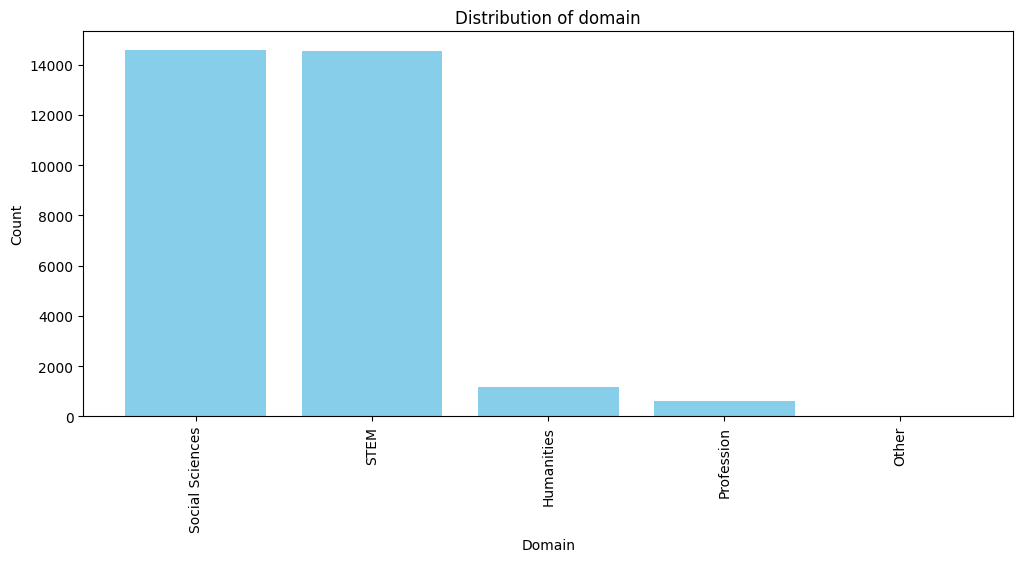

In [9]:
# len of unique subdomains
subdomains = [item['domain'] for item in data]
subdomain_counts = Counter(subdomains)
plt.figure(figsize=(12, 5))
# ascending order of subdomains based on count
subdomain_counts = dict(sorted(subdomain_counts.items(), key=lambda item: item[1],
                                    reverse=True))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='skyblue')
plt.title('Distribution of domain')
plt.xlabel('Domain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

In [10]:
subdomain_counts

{'Social Sciences': 14600,
 'STEM': 14556,
 'Humanities': 1160,
 'Profession': 595,
 'Other': 20}

In [11]:
len(data)

30931

In [12]:
# remove samples where has_image is True
data = [item for item in data if not item.get('has_image', False)]
len(data) 

30862

In [13]:
# remove the keys "page" and "source_url"
for item in data:
    if "page" in item:
        del item["page"]
    if "question_number" in item:
        del item["question_number"]
    if "has_image" in item:
        del item["has_image"]
    if "image_bbox" in item:
        del item["image_bbox"]
    if "page" in item:
        del item["page"]
    if "source_image" in item:
        del item["source_image"]
    if "folder" in item:
        del item["folder"]
    if "provider" in item:
        del item["provider"]
    if "model" in item:
        del item["model"]
    

In [14]:
data[0]

{'id': 0,
 'question': 'آرٹ کی اقسام ہوتی ہیں۔',
 'options': {'A': 'چار', 'B': 'ایک', 'C': 'دو', 'D': 'تین'},
 'domain': 'Humanities',
 'subdomain': 'art and drawing',
 'correct_option': None,
 'correct_index': None,
 'level': 'SSC-II',
 'source_url': '',
 'source': 'BISE Multan 2025'}

In [15]:
# start the id from 0 and make it incremental
for i, item in enumerate(data):
    item['id'] = i

In [ ]:
# save the updated data in a new json file
with open('3-consolidated/mcqs_without_answers.json', 'w') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)